In [15]:
import pandas as pd
import numpy as np
import warnings
from Bivariate import Bivariate
warnings.filterwarnings("ignore")

dataset = pd.read_csv("cleaned_ckd_dataset.csv")

dataset.drop('id',inplace=True, axis=1)

quan, qual = Bivariate.quanQual(dataset)

dataset.isna().sum()

age               0
bp                0
sg                0
al                0
su                0
rbc               0
pc                0
pcc               0
ba                0
bgr               0
bu                0
sc                0
sod               0
pot               0
hemo              0
pcv               0
wc                0
rc                0
htn               0
dm                0
cad               0
appet             0
pe                0
ane               0
classification    0
dtype: int64

In [26]:
dataset[quan].columns

Index(['age', 'bp', 'sg', 'al', 'su', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo',
       'pcv', 'wc', 'rc'],
      dtype='object')

### Covariance

In [16]:
dataset[quan].cov()

,age,bp,sg,al,su,bgr,bu,sc,sod,pot,hemo,pcv,wc,rc
age,302.148905,35.568759,-0.024540,2.299270,2.611679,277.299416,162.398832,12.899124,-18.664964,3.014453,-10.225328,-29.678102,5.682009e+03,-3.383869
bp,35.568759,198.917423,-0.020327,1.243536,2.609056,140.322814,111.852508,13.142100,-10.635257,3.888179,-10.114192,-31.228825,1.355184e+03,-2.161367
sg,-0.024540,-0.020327,0.000036,-0.002546,-0.001280,-0.137203,-0.104147,-0.010633,0.018179,-0.001366,0.010044,0.028751,-3.129597e+00,0.002618
al,2.299270,1.243536,-0.002546,1.787976,0.435222,34.753100,22.435153,1.003411,-2.389992,0.593405,-1.549655,-4.837359,9.449017e+02,-0.409240
su,2.611679,2.609056,-0.001280,0.435222,1.033364,41.794215,7.583912,0.784267,-0.370875,0.794607,-0.470259,-1.668149,3.912373e+02,-0.148304
bgr,277.299416,140.322814,-0.137203,34.753100,41.794215,5312.347121,460.882171,35.912506,-113.786234,19.402360,-55.862224,-160.909695,1.486029e+04,-14.816529
bu,162.398832,111.852508,-0.104147,22.435153,7.583912,460.882171,2548.067293,174.878416,-132.964603,62.826645,-68.763365,-190.945839,8.418257e+03,-16.724896
sc,12.899124,13.142100,-0.010633,1.003411,0.784267,35.912506,174.878416,33.250896,-41.710971,4.354062,-4.784141,-14.019575,7.613838e+01,-1.325987
sod,-18.664964,-10.635257,0.018179,-2.389992,-0.370875,-113.786234,-132.964603,-41.710971,104.910616,2.755472,7.861634,24.737319,2.583552e+02,2.397713
pot,3.014453,3.888179,-0.001366,0.593405,0.794607,19.402360,62.826645,4.354062,2.755472,11.267706,-0.977749,-3.556012,-5.729990e+02,-0.345190


### Correlation 

In [17]:
dataset[quan].corr()

,age,bp,sg,al,su,bgr,bu,sc,sod,pot,hemo,pcv,wc,rc
age,1.000000,0.145085,-0.236940,0.098923,0.147803,0.218875,0.185083,0.128691,-0.104835,0.051663,-0.219778,-0.215891,0.123438,-0.233994
bp,0.145085,1.000000,-0.241883,0.065939,0.181979,0.136505,0.157110,0.161595,-0.073621,0.082128,-0.267924,-0.279981,0.036284,-0.184202
sg,-0.236940,-0.241883,1.000000,-0.319497,-0.211342,-0.315930,-0.346268,-0.309463,0.297865,-0.068307,0.629770,0.610149,-0.198344,0.528213
al,0.098923,0.065939,-0.319497,1.000000,0.320187,0.356590,0.332386,0.130136,-0.174504,0.132207,-0.432983,-0.457442,0.266848,-0.367873
su,0.147803,0.181979,-0.211342,0.320187,1.000000,0.564087,0.147795,0.133794,-0.035620,0.232867,-0.172833,-0.207499,0.145336,-0.175359
bgr,0.218875,0.136505,-0.315930,0.356590,0.564087,1.000000,0.125268,0.085448,-0.152418,0.079304,-0.286346,-0.279157,0.076991,-0.244346
bu,0.185083,0.157110,-0.346268,0.332386,0.147795,0.125268,1.000000,0.600799,-0.257170,0.370784,-0.508942,-0.478315,0.062976,-0.398254
sc,0.128691,0.161595,-0.309463,0.130136,0.133794,0.085448,0.600799,1.000000,-0.706218,0.224944,-0.309970,-0.307427,0.004986,-0.276401
sod,-0.104835,-0.073621,0.297865,-0.174504,-0.035620,-0.152418,-0.257170,-0.706218,1.000000,0.080144,0.286761,0.305388,0.009525,0.281377
pot,0.051663,0.082128,-0.068307,0.132207,0.232867,0.079304,0.370784,0.224944,0.080144,1.000000,-0.108824,-0.133954,-0.064461,-0.123607


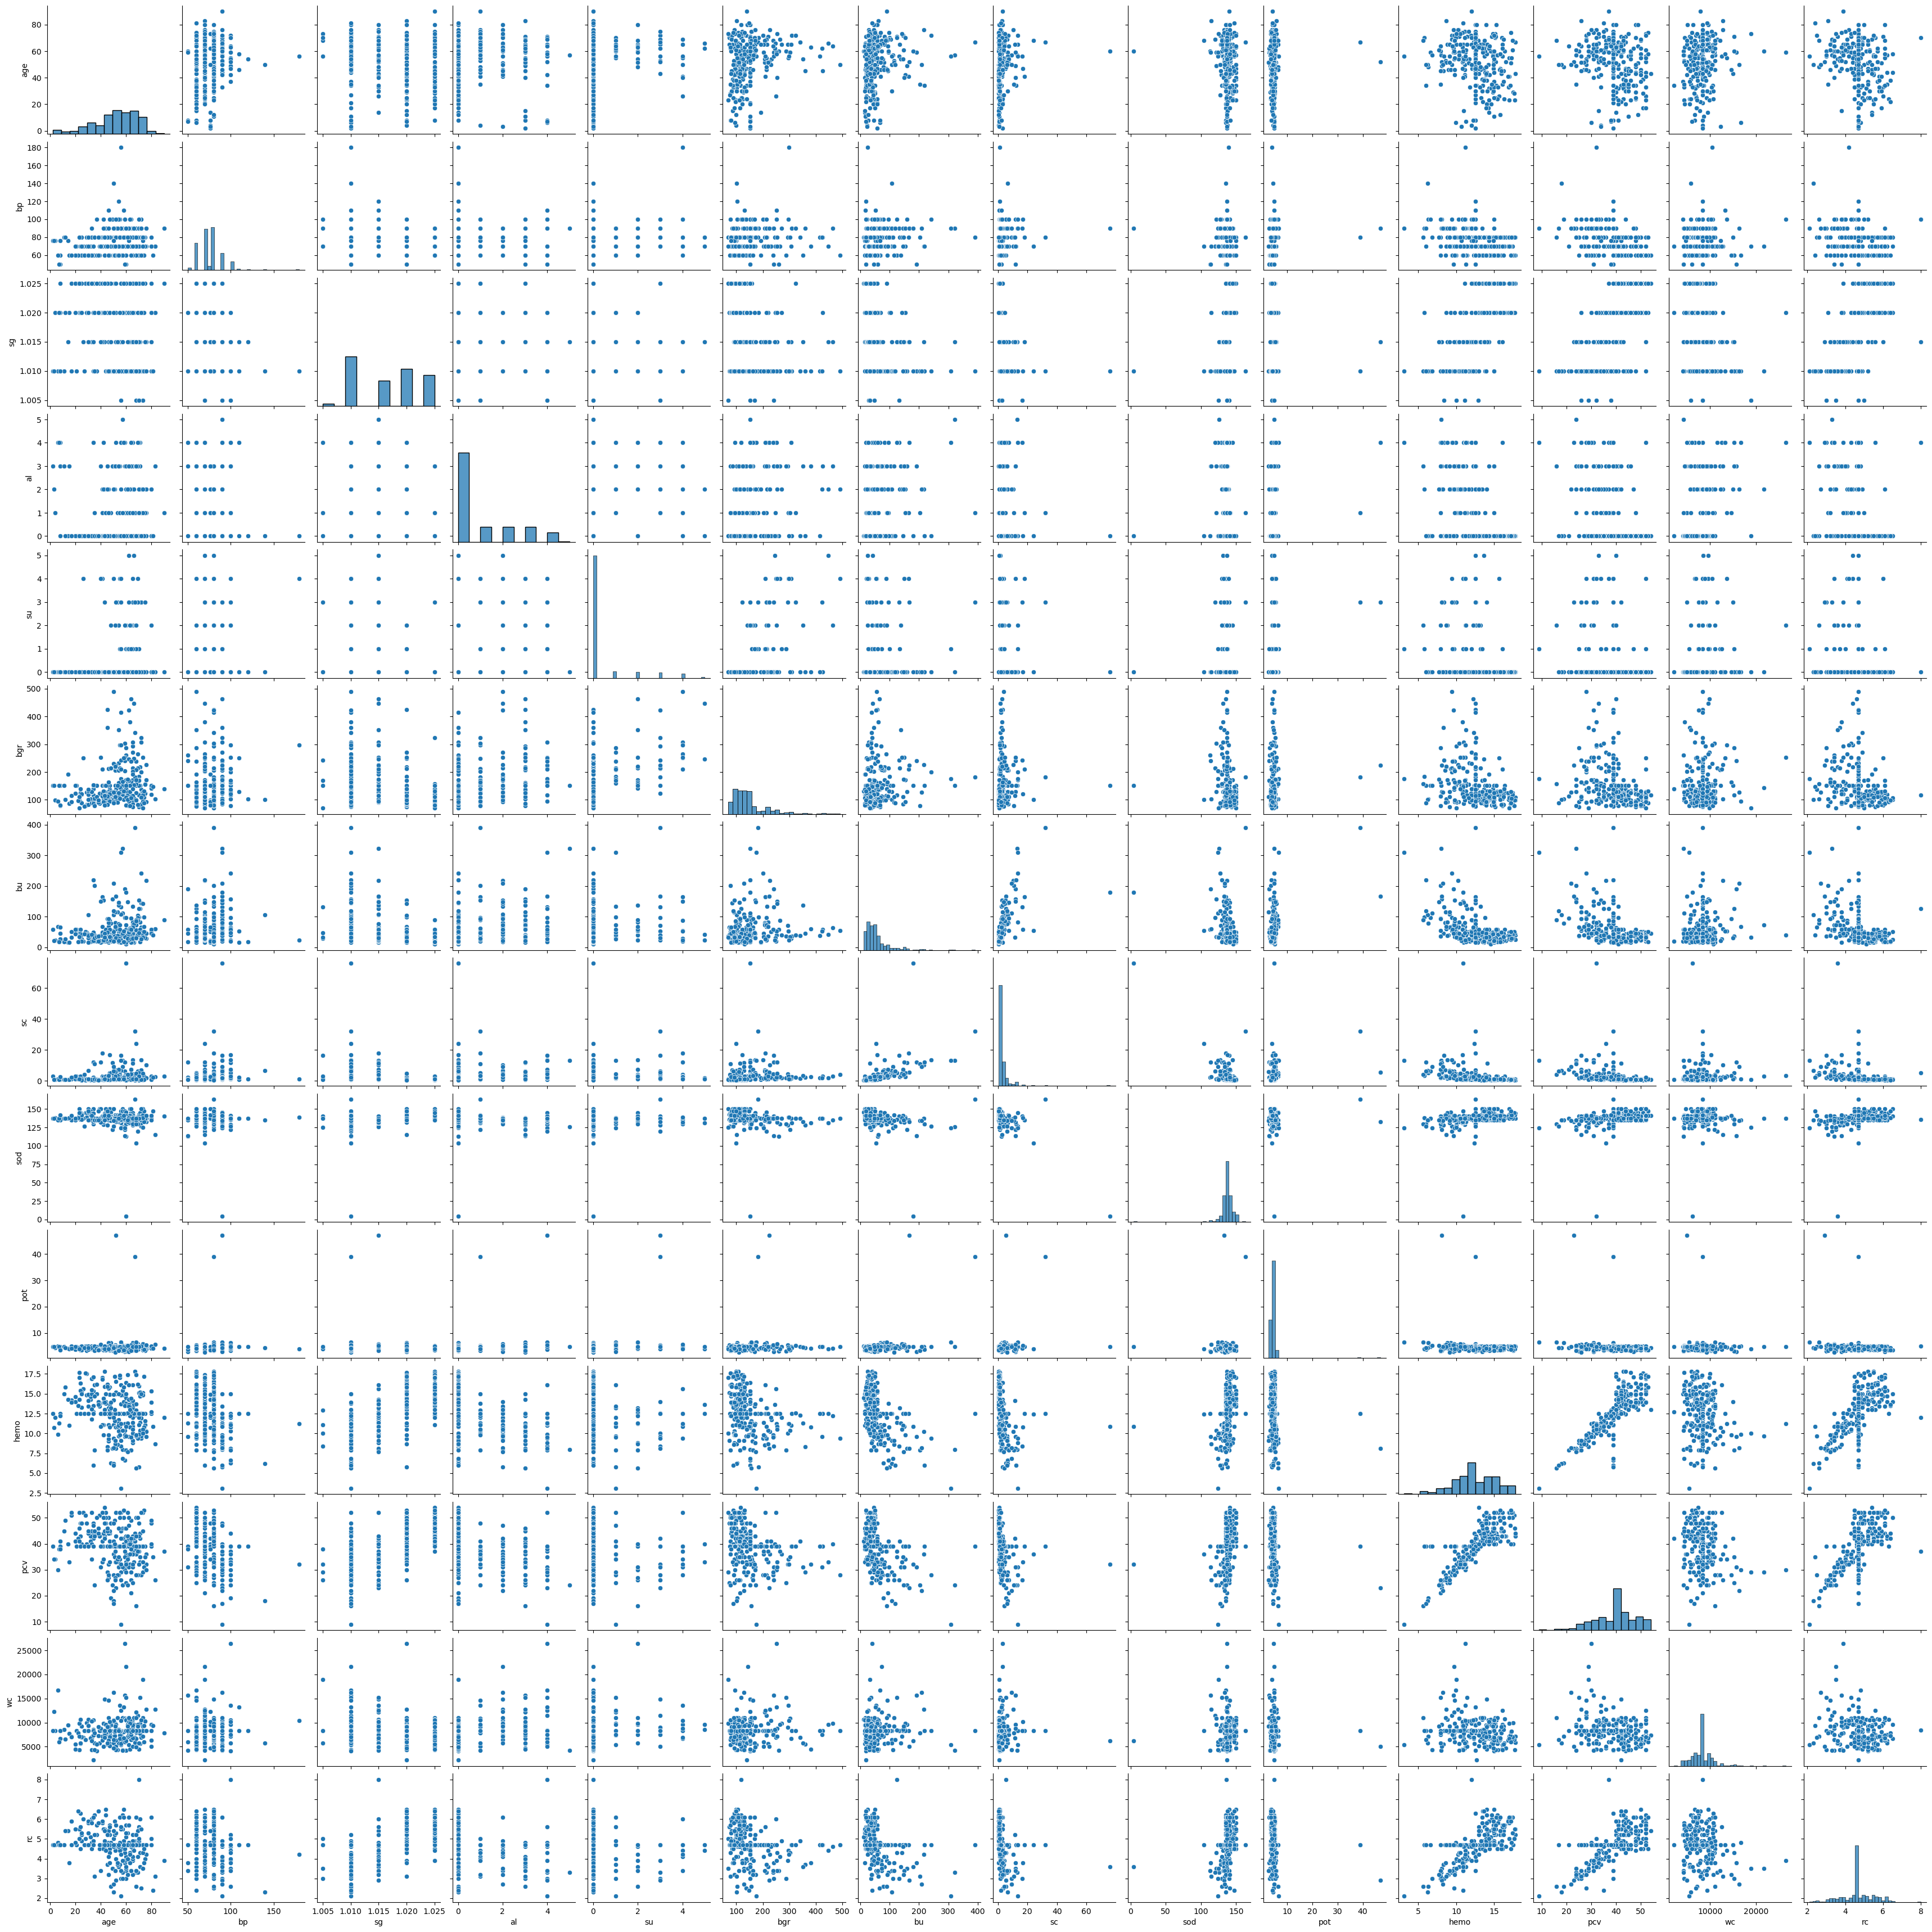

In [18]:
import seaborn as sns

sns.pairplot(dataset)

## Calculating VIF

In [24]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calc_vif(X):

    vif = pd.DataFrame()
    vif['variables']= X.columns
    vif['vif'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

    return vif

In [38]:
calc_vif(dataset[quan])

,variables,vif
0,age,11.042491
1,bp,34.604912
2,sg,577.354757
3,al,2.299881
4,su,1.920189
5,bgr,8.922089
6,bu,5.726903
7,sc,4.756842
8,sod,505.969782
9,pot,4.062608


## columns VIF > 5 have serious Multicollinearity, iteratively dropped columns one by one from largest till all VIFs <5

In [37]:
calc_vif(dataset[['al', 'su', 'bu', 'sc', 'pot', 'wc']])

,variables,vif
0,al,1.902266
1,su,1.339326
2,bu,4.331590
3,sc,2.037216
4,pot,3.164205
5,wc,3.046987
